In [1]:
import os
from glob import glob
import json
import yaml
import numpy as np
import torch
import argparse

import sys
from pathlib import Path
__abs_path__ = str(Path.cwd().parents[0].absolute())
__utils_path__ = f'{__abs_path__}/utils'

for __util_path__ in [__abs_path__, __utils_path__]:
    if not __util_path__ in sys.path:
        sys.path+=[__util_path__]
        
from evaluation import Options, Trainer
import pickle
import trimesh
from utils.remesh_utils import ICT_face_model
from utils.arg_util import YamlArgParser
from utils.matplotlib_rnd import (
    render_mesh_diff,
    plot_image_array
)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
## load checkpoint from originial NFR

ckpt = '' ## dummy ckpt
design='nfr'
dec_type = 'jacob'

config = f'{__abs_path__}/config/train.yml'
opts_yaml = yaml.load(open(config), Loader=yaml.FullLoader)
opts = argparse.Namespace(**opts_yaml)

opts.NFR = True
opts.dec_type = 'jacob'
opts.ckpt = '' ## ------> dummy ckpt
opts.design = 'nfr'

opts.device="cuda:0"

opts.data_rand_trans=False
opts.data_rand_scale=False
opts.learn_rig_emb=False
opts.use_decimate = False
opts.stage1 = True
opts.stage2 = False
opts.stage22 = False
opts.scale_exp = 1.0
opts.load_rigformer = False

trainer = Trainer(opts)

Loading... pretrained NFR


# Retarget single frame

(11248, 3)


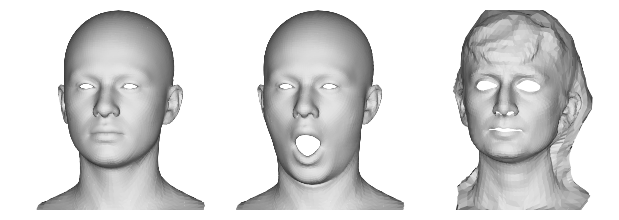

In [3]:
## full head
ict_face_model = ICT_face_model()
ict_tri = ict_face_model.get_mesh()

## flame
# flame_tri = trimesh.load(f'{abs_path}/test-mesh/flame_final_transformed.obj', process=False, maintain_order=True)
with open('/data/sihun/pca/multiface_align/mf_templates.pkl', 'rb') as f:
    mesh = pickle.load(f)
    mesh_list = [idname for idname in mesh.keys() if idname!='face']
    mesh_id = mesh_list[12]
flame_tri=trimesh.Trimesh(vertices=mesh[mesh_id],faces=mesh['face'])

## head mesh
# flame_tri = trimesh.load(f'{__abs_path__}/test-mesh/head-reference.obj', process=False, maintain_order=True)
# flame_tri.vertices = flame_tri.vertices*0.092 + np.array([0,-0.18,0])

## ICT random expression
bs_coeff = np.eye(53)[26]
vertices = torch.from_numpy(ict_tri.vertices + ict_face_model.get_exp_disp(bs_coeff))
src_mesh = ict_tri
tgt_mesh = flame_tri


print(ict_tri.vertices.shape)

M_SCALE = 0.68
v_list=[ ict_tri.vertices * M_SCALE, vertices[0] * M_SCALE, flame_tri.vertices * M_SCALE ]
f_list=[ ict_tri.faces, ict_tri.faces, flame_tri.faces ]
SIZE=2

plot_image_array(
    v_list, f_list,
    rot_list=[[0,-10,0]]*len(v_list), 
    size=SIZE, bg_black=False, mode='shade', 
    logdir=f"_tmp/train", 
    name=f"test", save=False
)

In [7]:
import time
import igl
asdas = time.time()
tmp_L = igl.cotmatrix(ict_tri.vertices, ict_tri.faces)
print(time.time() - asdas)

print(ict_tri.vertices.shape)

0.06197381019592285
(11248, 3)


In [10]:
# tmp_L #11248x11248

print(0.05*111 + 10.0*111)
print(9.0*111)

1115.55
999.0


In [ ]:
pred_outputs = trainer.model.inference(
    vertices=vertices, 
    src_mesh=src_mesh, 
    tgt_mesh=tgt_mesh
)

  0%|          | 0/1 [00:00<?, ?it/s]

> /source/sihun/NeuralFacialAnimation/utils/deformation_transfer.py(194)forward()
    192 
    193         import pdb;pdb.set_trace()
--> 194         batch_size = input.shape[0]
    195         input = input.reshape(input.shape[0], -1, 3)
    196         input = input.transpose(1, 0)



ipdb>  print(input.shape)


torch.Size([1, 10278, 3, 3])


ipdb>  print(shape)


...

> /source/sihun/NeuralFacialAnimation/utils/deformation_transfer.py(206)forward()
    204         # ctx.grad = from_dlpack(ctx.solver.solve(ctx.rhs.toarray()).toDlpack())
    205         # cupy_input = cupy.from_dlpack(to_dlpack(input))
--> 206         import pdb;pdb.set_trace()
    207         b = spmm(idxs, vals, m=shape[0], n=shape[1], matrix=input)
    208         b = cupy.from_dlpack(to_dlpack(b))



ipdb>  print(input.shape)


torch.Size([30834, 3])


ipdb>  print(shape)


(5223, 30834)


 source neutral 	|	 source expression 	|	 target neutral 	|	 target expression


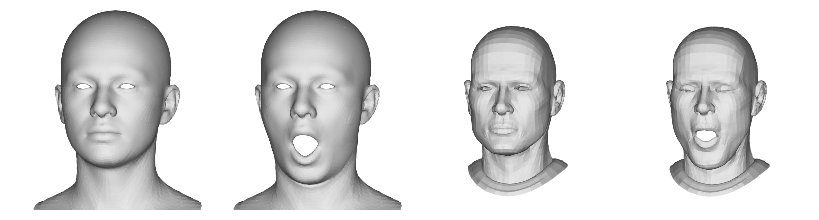

In [5]:
v_list=[ ict_tri.vertices * M_SCALE, vertices[0] * M_SCALE, flame_tri.vertices * M_SCALE, pred_outputs.detach().cpu().numpy()[0] * M_SCALE ]
f_list=[ ict_tri.faces, ict_tri.faces, flame_tri.faces, flame_tri.faces ]

print(' source neutral \t|\t source expression \t|\t target neutral \t|\t target expression')
plot_image_array(
    v_list, f_list,
    rot_list=[[0,-10,0]]*len(v_list), 
    size=SIZE, bg_black=False, mode='shade', 
    logdir=f"_tmp/train", 
    name=f"test", save=False
)

# Retarget animation

In [3]:
from dataloader_CBD import (
    EvalDataset,
    CBDDataBatch_eval,
    CBD_collate_wrapper_eval,
)
from functools import partial
from tqdm import tqdm
from glob import glob
import igl

from utils import nfr_utils
import trimesh
import pickle
import ipywidgets as widgets
import matplotlib.pyplot as plt

try:
    from matplotrender import *
except:
    !pip install git+https://github.com/chacorp/matplotrender.git
    from matplotrender import *

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
  Cloning https://github.com/chacorp/matplotrender.git to /tmp/pip-req-build-0tf7frkw
  Running command git clone --filter=blob:none --quiet https://github.com/chacorp/matplotrender.git /tmp/pip-req-build-0tf7frkw
  Resolved https://github.com/chacorp/matplotrender.git to commit 2ad6593a4e5846a8d7d5f80d47cd64160d4df35a
  Preparing metadata (setup.py) ... done
  Created wheel for matplotrender: filename=matplotrender-0.1.1-py3-none-any.whl size=10260 sha256=efb86026f14fd8339e802523e1ba88bfa59986c60592fc9a8dd4b87aa6d11764
  Stored in directory: /tmp/pip-ephem-wheel-cache-1j42zthf/wheels/90/4f/a0/55e49b720e59b00a00c9a6fc2e54648042fdce54d3be49c7ca
Successfully built matplotrender


In [4]:
def get_mesh(selection, dataset, SELECT_MESH):
    if selection=='ict'or selection=='ict-cap':
        # id_vecs = np.load(f'{__abs_path__}/data/ICT_live_100/iden_vecs.npy')
        # id_vecs = np.load(f'{__abs_path__}/ict_face_pt/random_identity_vecs.npy')[:101]
        id_vecs = torch.load(f'{__abs_path__}/ict_face_pt/ict_id_vecs_test.pt').numpy()
        id_disps = dataset.ict_face_model.get_id_disp(id_vecs[SELECT_MESH])
        mesh_v = dataset.ict_face_model.neutral_verts.squeeze() + id_disps.squeeze()
        
        return mesh_v, dataset.ict_face_model.faces
    else:
        if selection=='voca':
            mesh = dataset.voca_mesh
        elif selection=='biwi':
            # mesh = dataset.biwi_mesh            
            biwi_trimesh = trimesh.load(f'{__abs_path__}/test-mesh/BIWI.ply')
            with open(f'{__abs_path__}/test-mesh/biwi_templates.pkl', 'rb') as f:
                mesh = pickle.load(f)
                
            mesh['face']=biwi_trimesh.faces
        elif selection=='mf_SEN':
            mesh = dataset.mf_SEN_mesh
        elif selection=='coma':
            mesh = dataset.coma_mesh
        elif selection=='mf_ROM':
            mesh = dataset.mf_ROM_mesh

        mesh_list = [idname for idname in mesh.keys() if idname!='face']
        mesh_v = mesh[mesh_list[SELECT_MESH]]

        if selection=='biwi':
            m_align = np.load(f'{__abs_path__}/utils/biwi/align.npy')
            mesh_v = np.concatenate((mesh_v,np.ones((mesh_v.shape[0],1))), axis=1) @ m_align.T
        return mesh_v, mesh['face']

In [5]:
device='cuda:0'
SRC_SELECT_DATA=4
SRC_SELECT_MESH=12
EXP_NUM=0

BS=1
data_name_list = ['voca','biwi','mf_SEN','coma','mf_ROM','ict','ict-cap'] # 0 1 2 3 4 5 6
src_selection = data_name_list[SRC_SELECT_DATA]

src_dataset = EvalDataset(
    data_name=src_selection, 
    toggle=False, 
    ict_cap_id_num  = SRC_SELECT_MESH,
    ict_cap_exp_num = EXP_NUM,
) # if eve-s01

src_dataloader = torch.utils.data.DataLoader(
    src_dataset,
    batch_size=BS,
    collate_fn=partial(CBD_collate_wrapper_eval, device=device),
)
len_data = len(src_dataset)
len_dataloader = len(src_dataloader)
print(f'max data length: {len_data}')
print(f'max dataloader: {len_dataloader}')

src_v, src_f = get_mesh(src_selection, src_dataset, SRC_SELECT_MESH)
src_n = igl.per_vertex_normals(src_v, src_f)

mf ROM data list exists: /source/sihun/NeuralFacialAnimation/utils/data/mf_ROM_vertex_data_test.txt
max data length: 11649
max dataloader: 11649


In [11]:
TGT_SELECT_DATA=6
TGT_SELECT_mesh=11

data_name_list = ['voca','biwi','mf_SEN','coma','mf_ROM','ict','ict-cap']
tgt_selection = data_name_list[TGT_SELECT_DATA]

tgt_dataset = EvalDataset(data_name=tgt_selection, toggle=False) # if eve-s01

tgt_v, tgt_f = get_mesh(tgt_selection, tgt_dataset, TGT_SELECT_mesh)

tgt_n = igl.per_vertex_normals(tgt_v, tgt_f)
tgt_v_th = torch.tensor(tgt_v).float()[None].to(device)
tgt_n_th = torch.tensor(tgt_n).float()[None].to(device)

(5223, 3) (11248, 3)


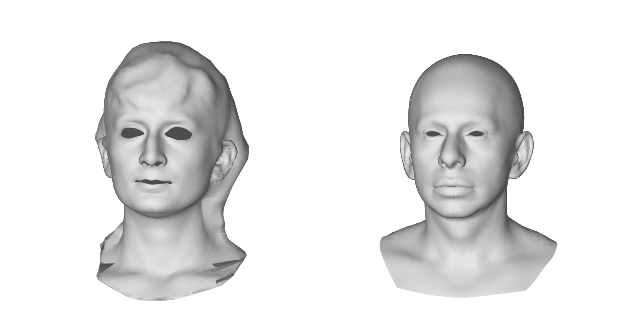

In [12]:
M_SCALE = 0.5
print(src_v.shape, tgt_v.shape)
v_list=[ src_v, tgt_v ]
f_list=[ src_f, tgt_f ]
SIZE=3
rot_list=[[0,-10,0]]

plot_mesh_gouraud(
    v_list, f_list, mesh_scale=M_SCALE,
    rot_list=rot_list*len(v_list), size=SIZE, mode='shade', bg_black=False
)

In [13]:
# file_name = 'coma-to-mf_ROM'
# file_name = 'mf_ROM_test-to-mf_ROM_val'
# file_name = 'mf_ROM_test-to-mf_ROM_test'
# file_name = 'mf_SEN_test-to-mf_SEN_test'
if src_selection == 'ict-cap':
    file_name = f'{src_selection}-ID_{SRC_SELECT_MESH:03d}_test-to-{tgt_selection}-ID_{TGT_SELECT_mesh:03d}_test_{EXP_NUM:02d}'
else:
    if 'ict' in  tgt_selection:
        # file_name = f'{src_selection}_test-to-{tgt_selection}_test-ID_{TGT_SELECT_mesh:03d}'
        file_name = f'{src_selection}_test-to-ict_test-ID_{TGT_SELECT_mesh:03d}'
    else:
        file_name = f'{src_selection}_test-to-{tgt_selection}_test'
        # file_name = f'{src_selection}_test-to-{tgt_selection}_test'
        # file_name = f'{src_selection}_test-to-{tgt_selection}_val'
        # file_name = f'{src_selection}_test-to-{tgt_selection}_train'
a2b_retarget_path = __abs_path__ + '/eval_CBD/nfr/'+file_name
print(a2b_retarget_path)
os.makedirs(a2b_retarget_path, exist_ok=True) 

/source/sihun/NeuralFacialAnimation/eval_CBD/nfr/mf_ROM_test-to-ict_test-ID_011


In [63]:
## Check!
FRAME=0
tgt_m = trimesh.Trimesh(vertices=tgt_v, faces=tgt_f)

pbar = tqdm(enumerate(src_dataloader), total=len_dataloader, ncols=100)
for index, batch in pbar:
    if index==0:
        src_m = trimesh.Trimesh(vertices=batch.template[0].cpu().numpy(), faces=batch.faces[0].cpu().numpy())
    else:
        if (batch.template[0].cpu().numpy() - src_m.vertices).mean() != 0:
            src_m = trimesh.Trimesh(vertices=batch.template[0].cpu().numpy(), faces=batch.faces[0].cpu().numpy())
            
    if FRAME == index:
        with torch.no_grad():
            pred_outputs = trainer.model.inference(
                vertices=batch.vertices, 
                src_mesh=src_m, 
                tgt_mesh=tgt_m
            )

        pred_outputs_np = pred_outputs.detach().cpu().numpy()
        for b_idx in range(BS):
            np.save(a2b_retarget_path+f'/{index*BS+b_idx:05d}', pred_outputs_np[b_idx])
        break
    else:
        continue

  0%|                                                                      | 0/3260 [00:20<?, ?it/s]


In [64]:
pred_outputs_np.shape

(1, 11248, 3)

     source neutral 	|	 source expression 	|	 target neutral 	|	 target expression


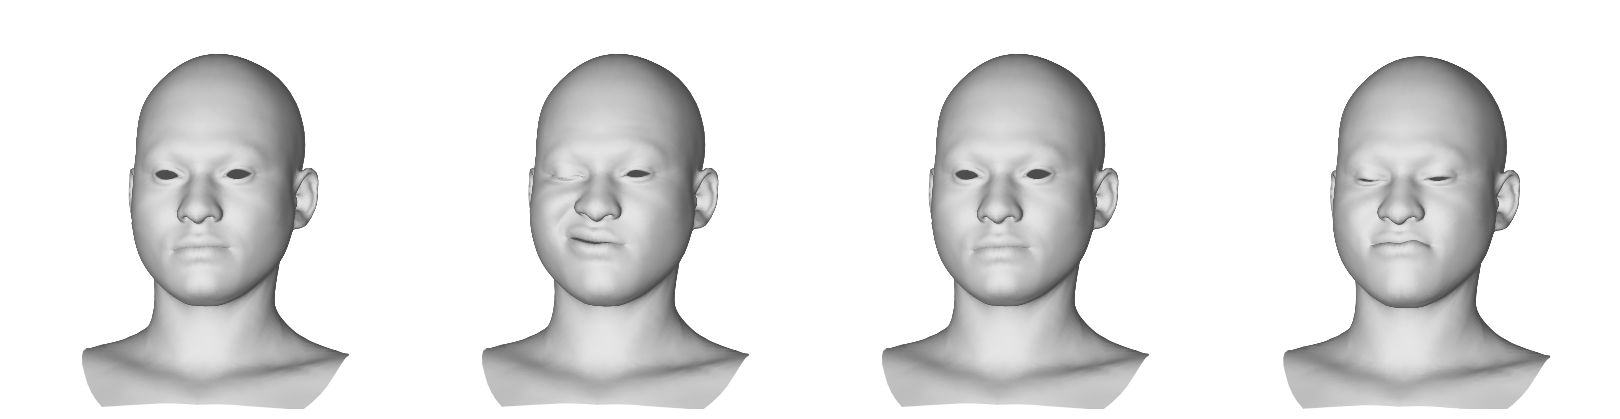

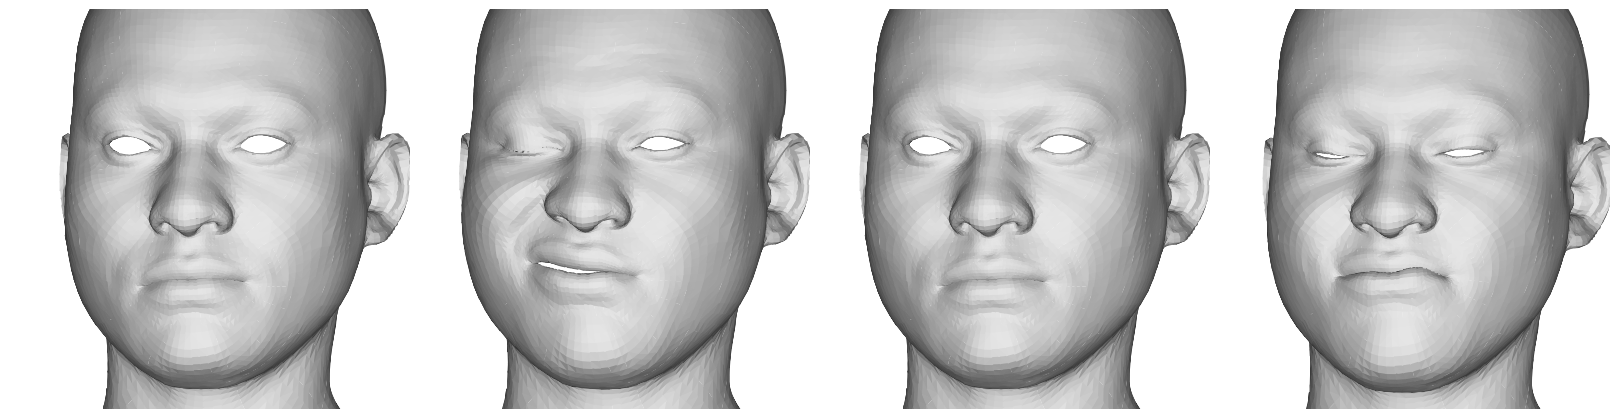

In [65]:
SIZE=6
M_SCALE=.7
SAVE=0
M_SCALE_zoom=1.3
M_trns=np.array([0,0.,0])

FRAME = 0

M_trns=np.array([0,0.,0])
v_list=[
    batch.template.detach().cpu().numpy()[FRAME],
    batch.vertices.detach().cpu().numpy()[FRAME],
    tgt_v,
    pred_outputs_np[FRAME],
]
v_list = [v * M_SCALE + M_trns for v in v_list]
f_list=[ src_f, src_f, tgt_f, tgt_f]

print('     source neutral \t|\t source expression \t|\t target neutral \t|\t target expression')
plot_mesh_gouraud(
    v_list, f_list, mesh_scale=M_SCALE,
    rot_list=rot_list*len(v_list), size=4,
    mode='shade', bg_black=False
)

v_list = [v * M_SCALE_zoom + M_trns for v in v_list]
plot_image_array(
    v_list, f_list,
    rot_list=rot_list*len(v_list), size=4,
    mode='shade', bg_black=False
)

In [44]:
# qwe=[]
# for asd in sorted(glob('/data/sihun/ICT-audio2face/templates/*_coeffs.pt')):
#     qwe.append(torch.load(asd)[None])
# qwe = torch.cat(qwe)
# print(qwe.shape)
# torch.save(qwe, '../ict_face_pt/ict_id_vecs_test.pt')

torch.Size([20, 100])


In [14]:
print(a2b_retarget_path)

/source/sihun/NeuralFacialAnimation/eval_CBD/nfr/mf_ROM_test-to-ict_test-ID_011


In [15]:
print(a2b_retarget_path)
SELF_RETARGET = SRC_SELECT_MESH==TGT_SELECT_mesh

if SELF_RETARGET:
    print('self-retargeting!')
    pbar = tqdm(enumerate(src_dataloader), total=len_dataloader, ncols=100)
    for index, batch in pbar:
        if index==0:
            src_verts = batch.template[0]
            src_faces = batch.faces[0]
            src_m = trimesh.Trimesh(vertices=batch.template[0].cpu().numpy(), faces=batch.faces[0].cpu().numpy())

            src_img = trainer.model.renderer.render_img(src_m).float().to(device)
            src_img_feat = trainer.model.get_img_feat(src_img)[None]
            src_dfn_info = nfr_utils.get_dfn_info(src_m, map_location=device)
            src_operators = trainer.model.get_mesh_operators(src_m)
        else:
            if (batch.template[0].cpu().numpy() - src_m.vertices).mean() != 0:            
                src_verts = batch.template[0]
                src_faces = batch.faces[0]
                src_m = trimesh.Trimesh(vertices=batch.template[0].cpu().numpy(), faces=batch.faces[0].cpu().numpy())

                src_img = trainer.model.renderer.render_img(src_m).float().to(device)
                src_img_feat = trainer.model.get_img_feat(src_img)[None]
                src_dfn_info = nfr_utils.get_dfn_info(src_m, map_location=device)
                src_operators = trainer.model.get_mesh_operators(src_m)

        with torch.no_grad():
            inputs_v = trainer.model.get_inputs(batch.vertices, batch.faces[0])# [B, V, 3+3]

            ## get expression
            trainer.model.model.update_precomputes(src_dfn_info)
            pred_exp = trainer.model.model.encode(inputs_v, src_img.to(device), N_F=src_m.faces.shape[0])
            pred_output, _, _ = trainer.model.calc_new_mesh(
                src_verts, src_faces, pred_exp, src_operators, src_dfn_info, src_img
            )
            pred_output_np = pred_output.detach().cpu().numpy()
            for b_idx in range(BS):
                if b_idx < batch.vertices.shape[0]:
                    np.save(a2b_retarget_path+f'/{index*BS+b_idx:05d}', pred_output_np[b_idx])
else:
    print('cross-retargeting!')
    tgt_m = trimesh.Trimesh(vertices=tgt_v, faces=tgt_f)
    tgt_dfn_info = nfr_utils.get_dfn_info(tgt_m, map_location=device)
    tgt_verts = tgt_v_th[0]
    tgt_faces = torch.from_numpy(tgt_m.faces).to(device)
    tgt_img = trainer.model.renderer.render_img(tgt_m).float().to(device)
    tgt_operators = trainer.model.get_mesh_operators(tgt_m)


    pbar = tqdm(enumerate(src_dataloader), total=len_dataloader, ncols=100)
    for index, batch in pbar:
        if index==0:
            src_m = trimesh.Trimesh(vertices=batch.template[0].cpu().numpy(), faces=batch.faces[0].cpu().numpy())

            src_img = trainer.model.renderer.render_img(src_m).float().to(device)
            src_img_feat = trainer.model.get_img_feat(src_img)[None]
            src_dfn_info = nfr_utils.get_dfn_info(src_m, map_location=device)
        else:
            if (batch.template[0].cpu().numpy() - src_m.vertices).mean() != 0:
                src_m = trimesh.Trimesh(vertices=batch.template[0].cpu().numpy(), faces=batch.faces[0].cpu().numpy())

                src_img = trainer.model.renderer.render_img(src_m).float().to(device)
                src_img_feat = trainer.model.get_img_feat(src_img)[None]
                src_dfn_info = nfr_utils.get_dfn_info(src_m, map_location=device)

        with torch.no_grad():
    #         for b_idx in range(BS):
    #             if b_idx < batch.vertices.shape[0]:

    #                 src_v_th = batch.vertices[b_idx]
    #                 inputs_v = trainer.model.get_inputs(src_v_th[None], batch.faces[0])# [1, V, 3+3]

    #                 ## get expression
    #                 trainer.model.model.update_precomputes(src_dfn_info)
    #                 pred_exp = trainer.model.model.encode(inputs_v, src_img.to(device), N_F=src_m.faces.shape[0])
    #                 pred_output, _, _ = trainer.model.calc_new_mesh(
    #                     tgt_verts, tgt_faces, pred_exp, tgt_operators, tgt_dfn_info, tgt_img
    #                 )
    #                 pred_output_np = pred_output.detach().cpu().numpy()[0]
    #                 np.save(a2b_retarget_path+f'/{index*BS+b_idx:05d}', pred_output_np)


            inputs_v = trainer.model.get_inputs(batch.vertices, batch.faces[0])# [B, V, 3+3]

            ## get expression
            trainer.model.model.update_precomputes(src_dfn_info)
            pred_exp = trainer.model.model.encode(inputs_v, src_img.to(device), N_F=src_m.faces.shape[0])
            pred_output, _, _ = trainer.model.calc_new_mesh(
                tgt_verts, tgt_faces, pred_exp, tgt_operators, tgt_dfn_info, tgt_img
            )
            pred_output_np = pred_output.detach().cpu().numpy()
            for b_idx in range(BS):
                if b_idx < batch.vertices.shape[0]:
                    np.save(a2b_retarget_path+f'/{index*BS+b_idx:05d}', pred_output_np[b_idx])

#                    93/204 [33:25<17:56,  9.70s/it] 3260/3260 [39:46<00:00,  1.37it/s]
### MF_rom self-retargeting 729/729 [05:24<00:00,  2.25it/s]

scp -r -P 32275 root@143.248.249.193:/source/sihun/NeuralFacialAnimation/eval_CBD/nfr/mf_ROM_test-to-ict_test-ID_011 ./eval_CBD/nfr/mf_ROM_test-to-ict_test-ID_011
    
scp -r -P 30669 /source/sihun/NeuralFacialAnimation/eval_CBD/nfr/mf_ROM_test-to-ict_test-ID_011 root@143.248.249.98:/source/sihun/NeuralFacialAnimation/eval_CBD/nfr/mf_ROM_test-to-ict_test-ID_011

/source/sihun/NeuralFacialAnimation/eval_CBD/nfr/mf_ROM_test-to-ict_test-ID_011
cross-retargeting!


100%|█████████████████████████████████████████████████████████| 11649/11649 [13:34<00:00, 14.31it/s]


In [16]:
pred_output_np.shape

(1, 11248, 3)

In [115]:
# file_name = 'GT-mf_ROM_test-to-mf_ROM_test'
# GT_file_name = 'GT-'+file_name
GT_file_name = f'GT-{src_selection}_test-to-{src_selection}_test'

GT_a2b_retarget_path = __abs_path__ + '/eval_CBD/'+ GT_file_name
print(GT_a2b_retarget_path)
os.makedirs(GT_a2b_retarget_path, exist_ok=True)

/source/sihun/NeuralFacialAnimation/eval_CBD/GT-ict-cap_test-to-ict-cap_test


In [118]:
pbar = tqdm(enumerate(src_dataloader), total=len_dataloader, ncols=100)
for index, batch in pbar:
    gt_outputs_np = batch.vertices.detach().cpu().numpy()
    for b_idx in range(BS):
        if b_idx < gt_outputs_np.shape[0]:
            np.save(GT_a2b_retarget_path+f'/{index*BS+b_idx:05d}', gt_outputs_np[b_idx])

100%|█████████████████████████████████████████████████████████████| 183/183 [01:44<00:00,  1.75it/s]


In [79]:
print(GT_a2b_retarget_path+f'/{index*BS+b_idx:05d}')
gt_outputs_np[b_idx].shape

/source/sihun/NeuralFacialAnimation/eval_CBD/GT-ict_test-to-ict_test/03259


(11248, 3)

In [159]:
print(a2b_retarget_path)
mesh_file_paths = sorted(glob(a2b_retarget_path+'/*.npy'))
len_mesh_file_paths=len(mesh_file_paths)
print(len(mesh_file_paths))

print(GT_a2b_retarget_path)
GT_mesh_file_paths = sorted(glob(GT_a2b_retarget_path+'/*.npy'))
GT_len_mesh_file_paths=len(GT_mesh_file_paths)
print(len(GT_mesh_file_paths))

/source/sihun/NeuralFacialAnimation/eval_CBD/nfr/ict-cap-ID_000_test-to-mf_ROM-ID_012_test_01
1147
/source/sihun/NeuralFacialAnimation/eval_CBD/GT-ict-cap_test-to-ict-cap_test
183


In [83]:
# src_dataset.iden_vecs[10]
# batch.template.shape
mesh_file_paths[0]

'/source/sihun/NeuralFacialAnimation/eval_CBD/nfr/ict_test-to-ict_test/00000.npy'

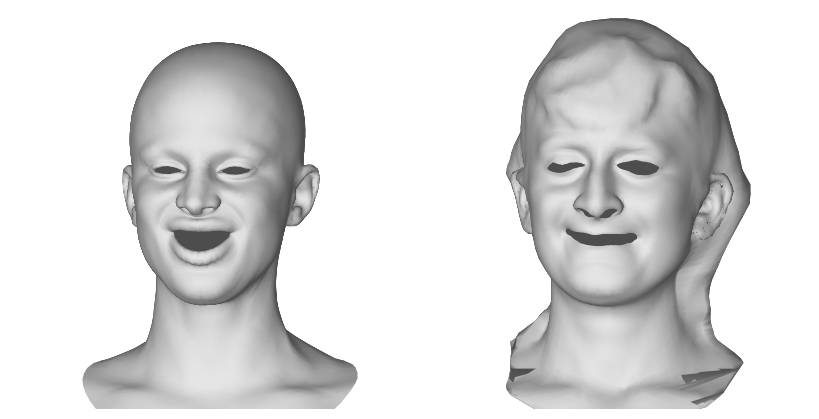

In [161]:
SAVE=0
rot_list=[[0,-10,0]]
M_SCALE=0.6

frame=163
# print(index)
vvvGT= np.load(GT_mesh_file_paths[frame]).squeeze()
vvv= np.load(mesh_file_paths[frame]).squeeze()
# qwe1 = batch.vertices[0].detach().cpu().numpy()
# qwe2 = batch.template[-1].detach().cpu().numpy()

v_list = [vvvGT, vvv]
f_list = [src_f, tgt_f]
plot_mesh_gouraud(
    v_list, f_list, mesh_scale=M_SCALE,
    rot_list=rot_list*len(v_list), size=4, mode='shade', bg_black=False)

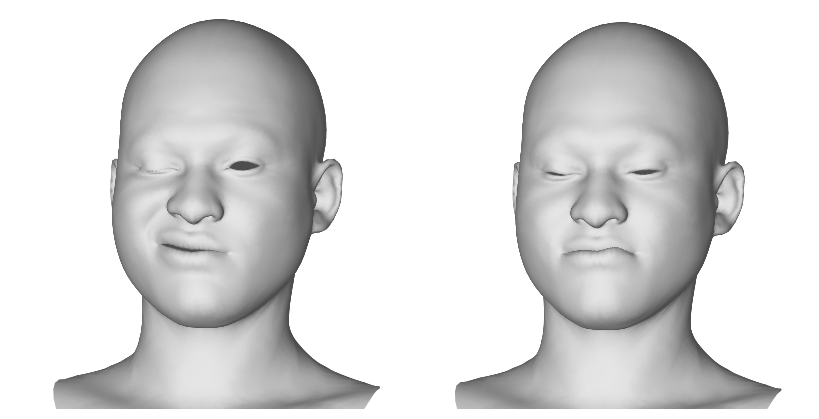

interactive(children=(IntSlider(value=0, description='Frame:', max=3259), Output()), _dom_classes=('widget-int…

In [14]:
SAVE=0
rot_list=[[0,-10,0]]
M_SCALE=0.6
def update_frame(frame):
    plt.close()
    
    vvv= np.load(mesh_file_paths[frame]).squeeze()
    vvvGT= np.load(GT_mesh_file_paths[frame]).squeeze()
    
    v_list = [vvvGT, vvv]
    f_list = [tgt_f]*len(v_list)
    plot_mesh_gouraud(
        v_list, f_list, mesh_scale=M_SCALE,
        rot_list=rot_list*len(v_list), size=4, mode='shade', bg_black=False)

slider = widgets.IntSlider(value=0, min=0, max=len_mesh_file_paths-1, step=1, description='Frame:')

widgets.interactive(update_frame, frame=slider)
# widgets.interact(update_frame, frame=slider)